In [1]:
%pip install --upgrade nbformat ipython

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install plotly us

Note: you may need to restart the kernel to use updated packages.


1. Data Preparation:

 - Download and explore the US Superstore data.

 - Perform basic data cleaning and preprocessing.

In [12]:
import pandas as pd
import xlrd as xlrd
import matplotlib.pyplot as plt
import plotly.express as px
import us
import seaborn as sns
from ipywidgets import interact, Dropdown

In [4]:
df = pd.read_excel('US Superstore data.xls')

In [5]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

In [7]:
# Check for missing values during preprocessing
missing_values = df.isnull().sum()
print("Missing values by column:")
print(missing_values)
print(f"\nTotal missing values: {missing_values.sum()}")

Missing values by column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total missing values: 0


In [8]:
df.duplicated().sum()

np.int64(0)

2. Data Visualization with Matplotlib:
 - Create an interactive line chart to show sales trends over the years.
 - Build an interactive map to visualize sales distribution by country.

In [ ]:
# Prepare the date and year columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Order Year'] = df['Order Date'].dt.year

#Create an interactive line chart to show sales trends over the years.

def plot_yearly_sales(category='All'):
    # Filter by category
    if category == 'All':
        filtered_df = df
    else:
        filtered_df = df[df['Category'] == category]

    # Calculate sales for each year
    yearly_sales = (
        filtered_df.groupby('Order Year')['Sales']
        .sum()
        .sort_index()
    )

    # Create the chart
    plt.figure(figsize=(10, 6))

    plt.plot(
        yearly_sales.index,
        yearly_sales.values,
        marker='o',
        markersize=8,
        linewidth=2,
        color='steelblue'
    )

    # Add value labels
    for year, sales in yearly_sales.items():
        plt.annotate(
            f'${sales:,.0f}',
            (year, sales),
            textcoords='offset points',
            xytext=(0, 10),
            ha='center'
        )

    plt.title(
        f'Annual Sales Trend — {category}',
        fontsize=16,
        fontweight='bold'
    )
    plt.xlabel('Order Year')
    plt.ylabel('Total Sales ($)')
    plt.xticks(yearly_sales.index)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


# Create the category selector
line_categories = ['All'] + sorted(df['Category'].dropna().unique())

line_category_dropdown = Dropdown(
    options=line_categories,
    value='All',
    description='Category:'
)

interact(
    plot_yearly_sales,
    category=line_category_dropdown
);

interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

In [ ]:
#Build an interactive map to visualize sales distribution by state.
def plot_state_sales(category='All'):
    # Filter by the selected category
    if category == 'All':
        filtered_df = df
    else:
        filtered_df = df[df['Category'] == category]

    # Calculate total sales by state
    state_sales = (
        filtered_df.groupby('State', as_index=False)['Sales']
        .sum()
    )

    # Convert full state names to two-letter abbreviations
    state_sales['State Code'] = state_sales['State'].apply(
        lambda state: us.states.lookup(state).abbr
        if us.states.lookup(state)
        else None
    )

    # Create the interactive state map
    fig = px.choropleth(
        state_sales,
        locations='State Code',
        locationmode='USA-states',
        scope='usa',
        color='Sales',
        hover_name='State',
        hover_data={
            'State Code': False,
            'Sales': ':,.2f'
        },
        color_continuous_scale='Blues',
        title=f'Sales Distribution by State — {category}'
    )

    fig.update_layout(
        coloraxis_colorbar_title='Total Sales ($)',
        margin=dict(l=0, r=0, t=50, b=0)
    )

    fig.show()


map_categories = ['All'] + sorted(df['Category'].dropna().unique())

map_category_dropdown = Dropdown(
    options=map_categories,
    value='All',
    description='Category:'
)

interact(plot_state_sales, category=map_category_dropdown);


interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

3. Data Visualization with Seaborn:
 - Use Seaborn to generate a bar chart showing top 10 products by sales.
 - Create a scatter plot to analyze the relationship between profit and discount.

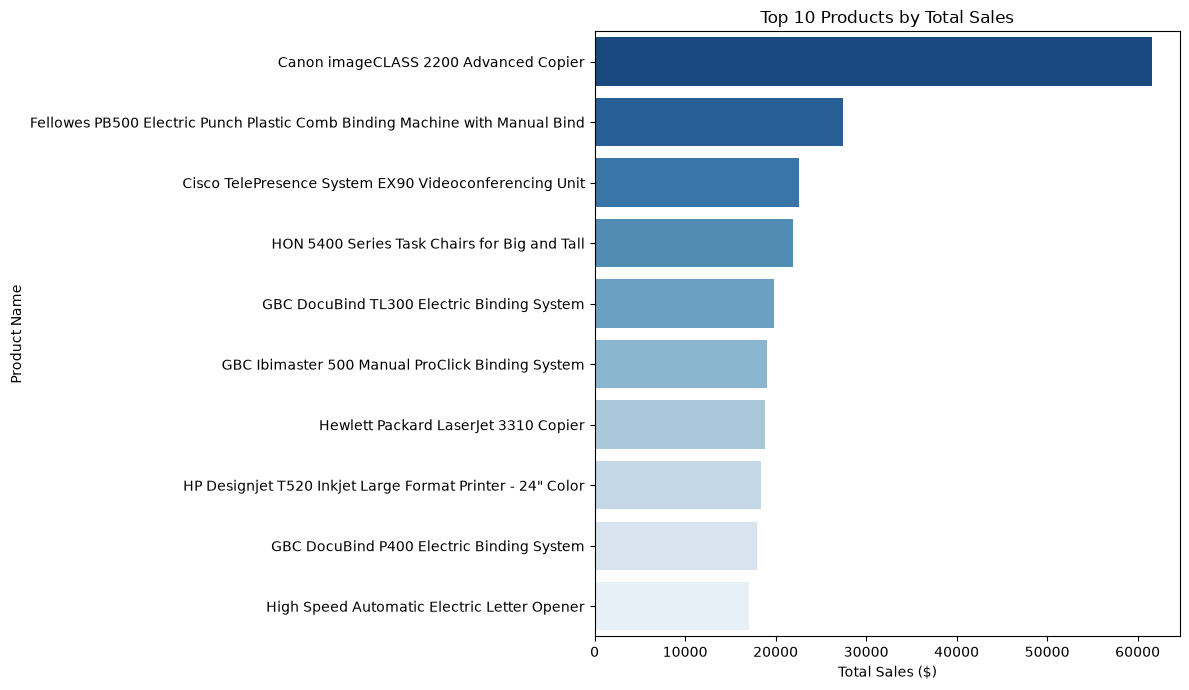

In [ ]:
#Use Seaborn to generate a bar chart showing top 10 products by sales.

top_10_products = (
    df.groupby('Product Name', as_index=False)['Sales']
    .sum()
    .nlargest(10, 'Sales')
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=top_10_products,
    x='Sales',
    y='Product Name',
    hue='Product Name',
    palette='Blues_r',
    legend=False
)

ax.set_title('Top 10 Products by Total Sales')
ax.set_xlabel('Total Sales ($)')
ax.set_ylabel('Product Name')

plt.tight_layout()
plt.show()

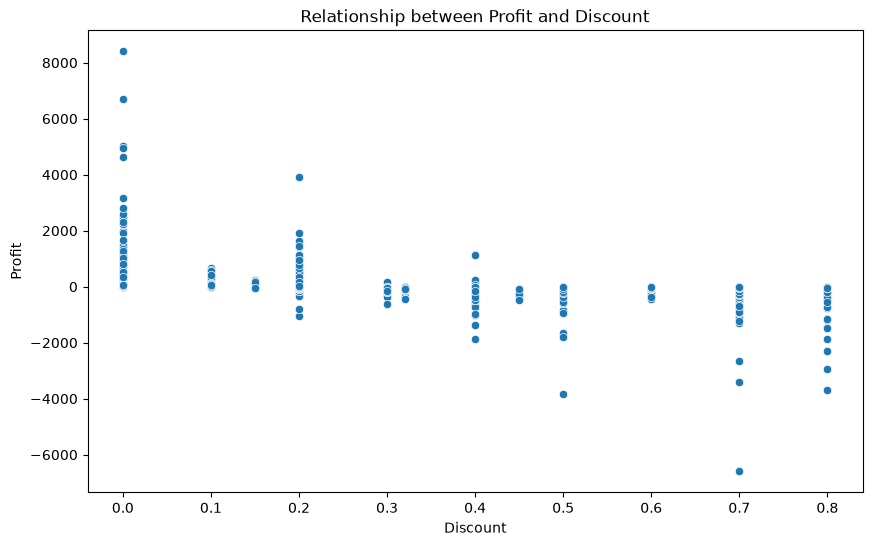

In [17]:
#Create a scatter plot to analyze the relationship between profit and discount.
profit_discount_df = df[['Profit', 'Discount']].dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=profit_discount_df, x='Discount', y='Profit')
plt.title('Relationship between Profit and Discount')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

4. Comparative Analysis:
 - Compare the insights gained from Matplotlib and Seaborn visualizations.
 - Document your observations about the ease of use and effectiveness of both tools.

## 4. Comparative Analysis

Matplotlib was useful for quickly exploring yearly sales trends and worked well with interactive widgets. However, creating a polished chart required more manual customization.

Seaborn made it easy to create clean product and discount visualizations with less styling code. Its professional defaults make it more suitable for stakeholder presentations.

Overall, **Matplotlib is preferable for rapid exploration**, while **Seaborn is preferable for stakeholder-facing visualizations**. Plotly was used for the interactive state map.